# Workflow widgets example

This notebook illustrates how we can use ESSreduce's [workflow widgets](https://scipp.github.io/essreduce/user-guide/widget.html) to generate a graphical interface for running the [DREAM GEANT4 workflow](./dream-powder-reduction.rst).

## Initializing the GUI

It is as simple as importing the dream submodule and generating a GUI using `workflow_widget` (the workflow automatically registers itself to a library of workflows when imported).

In [1]:
# Import dream submodule to register workflow
from ess import dream
from ess.reduce import ui

# Prepare a container for accessing the results computed by the GUI
results = {}

# Initialize the GUI widget
widget = ui.workflow_widget(result_registry=results)
widget

In [2]:
from ess.powder.types import DspacingBins, Filename, SampleRun, VanadiumRun
import ess.dream.data  # noqa: F401
from ess.dream import InstrumentConfiguration

select = widget.children[0].children[0]
keys, values = zip(*select.options, strict=True)
ind = keys.index("DreamGeant4ProtonChargeWorkflow")
select.value = values[ind]
# Select IofDspacing output
wfw = widget.children[1].children[0]
outputs = wfw.output_selection_box.typical_outputs_widget
keys, values = zip(*outputs.options, strict=True)
ind = keys.index("IntensityDspacing[SampleRun]")
outputs.value = (values[ind],)
# Refresh parameters
pbox = wfw.parameter_box
pbox.parameter_refresh_button.click()
# Set parameters
pbox._input_widgets[Filename[SampleRun]].children[0].value = str(dream.data.simulated_diamond_sample())
pbox._input_widgets[Filename[VanadiumRun]].children[0].value = str(dream.data.simulated_vanadium_sample())
pbox._input_widgets[InstrumentConfiguration].value = InstrumentConfiguration.high_flux_BC215
pbox._input_widgets[DspacingBins].fields["stop"].value = 2.3434
# Run the workflow
rbox = wfw.result_box
rbox.run_button.click()

## Accessing the results

We can now access the computed result in the `results` dictionary:

In [3]:
results

{ess.powder.types.IntensityDspacing[ess.reduce.nexus.types.SampleRun]: <scipp.DataArray>
 Dimensions: Sizes[dspacing:200, ]
 Coordinates:
 * detector                   string        <no unit>  ()  "mantle"
 * dspacing                  float64             [Å]  (dspacing [bin-edge])  [0, 0.011717, ..., 2.33168, 2.3434]
 Data:
                           DataArrayView        <no unit>  (dspacing)  binned data: dim='event', content=DataArray(
           dims=(event: 1267407),
           data=float64[dimensionless],
           coords={'event_time_zero':datetime64[ns], 'wavelength':float64[Å],
                   'dspacing':float64[Å]})
 Masks:
   zero_vanadium                bool        <no unit>  (dspacing)  [True, True, ..., False, False]
 }

The result can be plotted using

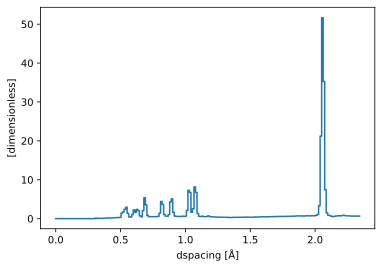

In [4]:
(da,) = results.values()
da.hist(dspacing=200).plot()